In [1]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import os

#import foldseek easy-search output. Constitutes pairwise tm-align analysis of high-lDDT ARP structures
df_train = pd.read_csv("subjects.out",sep='\t',header=None)

df_train.columns=['query','subject','tmscore','qtmscore','ttmscore','id','qlen','alnlen','tlen']
df_train['query'] = df_train['query'].str.replace('.pdb$', '', regex=True)
df_train['subject'] = df_train['subject'].str.replace('.pdb$', '', regex=True)

df_train['seqID']=(df_train.alnlen/df_train.tlen)*df_train.id
df_train = df_train[df_train['query'] != df_train['subject']]
df_train['coverage']=(df_train.tlen/df_train.qlen)

X_train = df_train[['seqID', 'ttmscore']].values

#scale and train one-class SVM on distribution
scaler = StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)

svm_model = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=1 / len(X_train)
)
svm_model.fit(X_train_scaled)

OneClassSVM(gamma='auto', nu=0.00040816326530612246)

In [2]:
#import foldseek easy-search output of queries against subjects in training set
df_queries = pd.read_csv("querys.out", sep='\t', header=None)

df_queries.columns = [
    'query', 'subject', 'tmscore', 'qtmscore', 'ttmscore',
    'id', 'qlen', 'alnlen', 'tlen'
]

df_queries['query'] = df_queries['query'].str.replace('.pdb$', '', regex=True)
df_queries['subject'] = df_queries['subject'].str.replace('.pdb$', '', regex=True)

df_queries['seqID'] = (df_queries.alnlen / df_queries.tlen) * df_queries.id
df_queries = df_queries[df_queries['query'] != df_queries['subject']]
df_queries['coverage'] = df_queries.tlen / df_queries.qlen
for query in df_queries['query'].unique():
    df_query = df_queries[df_queries['query'] == query]

    if df_query.empty:
        continue

    X_query = df_query[['seqID', 'ttmscore']].values
    X_query_scaled = scaler.transform(X_query)

    decision_values = svm_model.decision_function(X_query_scaled)

    if np.any(decision_values >= 0):
        print(
            f"✔ {query} functional "
            f"(best decision value = {decision_values.max():.4f})"
        )
    else:
        print(
            f"✘ {query} non-functional "
            f"(best decision value = {decision_values.max():.4f})"
        )



✘ A0A377FG49 non-functional (best decision value = -0.1963)
✘ A0A377FG49_mutated non-functional (best decision value = -0.1964)


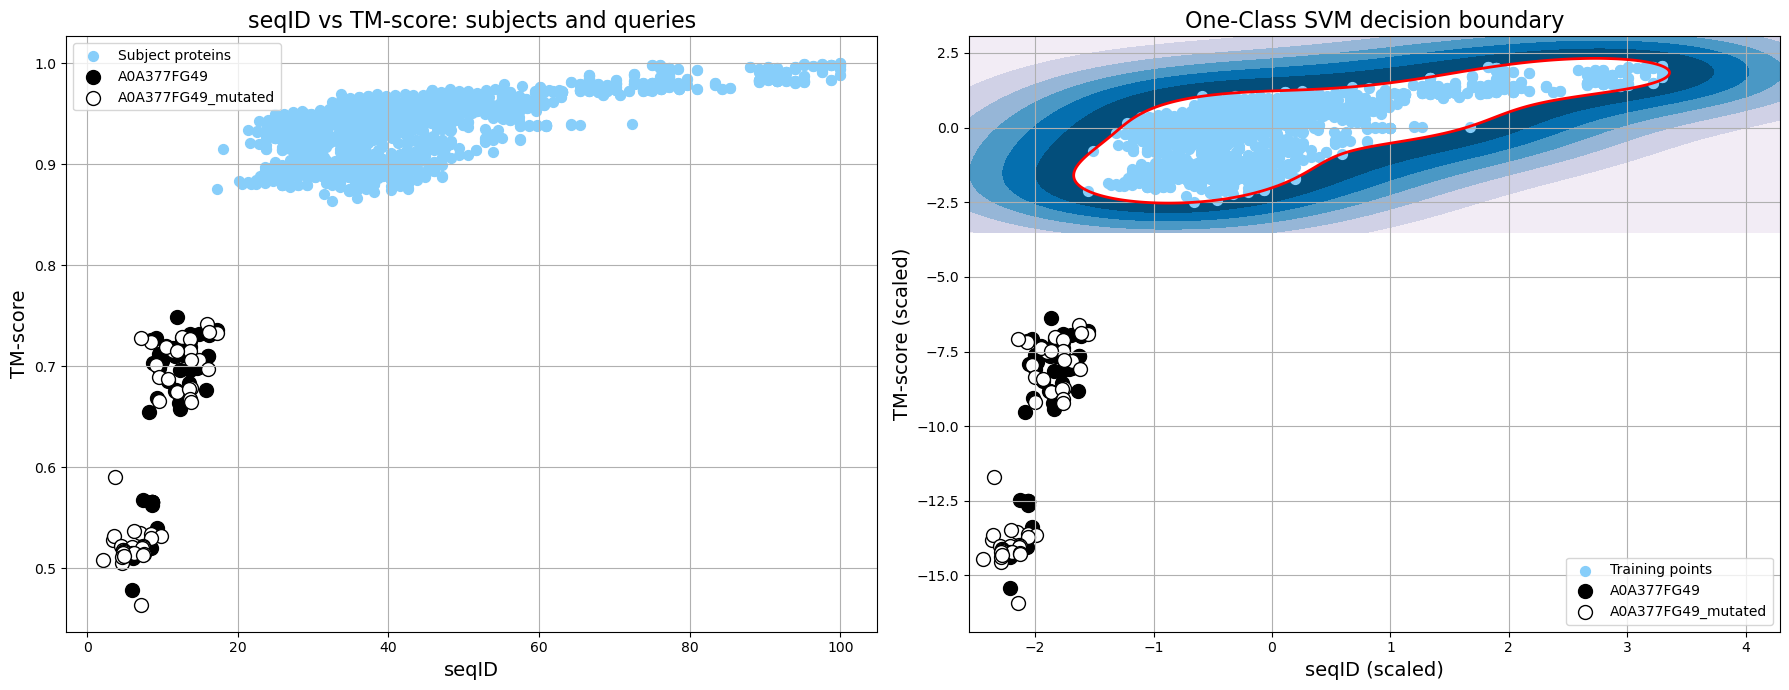

In [3]:
#create plots for visualisation

files = [f for f in os.listdir("/path/to/query/pdb/files") if f.endswith('.pdb')]

query = [os.path.splitext(f)[0] for f in files]  

#populate with different queries as necessary
query_to_color = {
    'query A': 'black',
    'query B': 'white'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]

# Training (subjects)
ax.scatter(
    df_train['seqID'],
    df_train['ttmscore'],
    s=50,
    color='lightskyblue',
    label='Subject proteins'
)

# Queries
queries = sorted(df_queries['query'].unique())
for query in queries:
    df_query = df_queries[df_queries['query'] == query]
    ax.scatter(
        df_query['seqID'],
        df_query['ttmscore'],
        s=100,
        color=query_to_color[query],
        edgecolors='k',
        label=query
    )

ax.set_title(
    'seqID vs TM-score: subjects and queries',
    fontsize=16
)
ax.set_xlabel('seqID', fontsize=14)
ax.set_ylabel('TM-score', fontsize=14)
ax.grid(True)
ax.legend(loc='best', fontsize=10)


ax = axes[1]

xx, yy = np.meshgrid(
    np.linspace(X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1, 500),
    np.linspace(X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1, 500)
)

Z = svm_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Decision boundary
ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu)
ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red')

# Training points (scaled)
ax.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c='lightskyblue',
    s=50,
    label='Training points'
)

# Query points (scaled)
for query in queries:
    df_query = df_queries[df_queries['query'] == query]
    X_query = df_query[['seqID', 'ttmscore']].values
    X_query_scaled = scaler.transform(X_query)

    ax.scatter(
        X_query_scaled[:, 0],
        X_query_scaled[:, 1],
        s=100,
        color=query_to_color[query],
        edgecolors='k',
        label=query
    )

ax.set_title(
    'One-Class SVM decision boundary',
    fontsize=16
)
ax.set_xlabel('seqID (scaled)', fontsize=14)
ax.set_ylabel('TM-score (scaled)', fontsize=14)
ax.grid(True)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()
